<div>
<img src="https://www.smu.edu.sg/themes/smubase_5g/assets/site-headers/logo-smu-d.svg?revised=20240229" width="200" align="center">
</div>

# Predicting Residential House Prices in Ames, Iowa
### ACCT682 Programming for Business Analytics — Team Project

**Group / class section:** *G#*

| Team member (alphabetical) | Student ID |
| --- | --- |
| *Andersen, Marius* | *ID* |
| *Clarysse Jelke* | *ID* |
| *name* | *ID* |
| *Kukreja, Siddharth Yash* | *ID* |

**Instructor:** Dr Wang Jiwei  |  **Submitted:** August 2026

---

Runs in about a minute. `train.csv` and `test.csv` are in the same folder as this notebook, so all paths are relative.

# 1. Introduction

*To write, ~4 paragraphs:*
- *the business problem, and why 79 recorded attributes should be enough to price a house*
- *the data: 1,460 labelled sales, 1,459 unlabelled, Ames Iowa 2006-2010 (De Cock, 2011)*
- *the metric: RMSE on log(SalePrice), so a 10% error costs the same on a cheap house as an expensive one*
- *preview: which cleaning decision mattered most, which models we used, final score*

Source: Kaggle, *House Prices - Advanced Regression Techniques*.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Lasso, RidgeCV, LassoCV
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(f"train: {train.shape}, test: {test.shape}")
print(train.dtypes.value_counts())

train: (1460, 81), test: (1459, 80)
object     43
int64      35
float64     3
Name: count, dtype: int64


# 2. Exploratory data analysis

## 2.1 The target

*As shown in the figure below, sale prices are heavily right-skewed, with a skewness of 1.88. This indicates that a small number of high-priced homes, well beyond the typical price range, are pulling the distribution to the right. In a skewed distribution, the mean and median diverge—the mean is pulled toward the extreme values, while the median remains a more representative measure of the “typical” home price.*

*This skew can create challenges for regression modelling. Many regression models are trained using squared-error loss, which penalizes large errors disproportionately more than small ones. As a result, the small number of high-priced homes can have a strong influence on the loss function, shifting the model’s focus away from the broader market and making it more sensitive to extreme values.*

*To address this, we applied a log transformation to sales price , reducing skewness from 1.88 to 0.12 and producing a much more symmetric distribution that may be better suited for modelling. This transformation reduces the relative influence of extreme prices and may support more reliable and generalizable predictions in future modelling.*


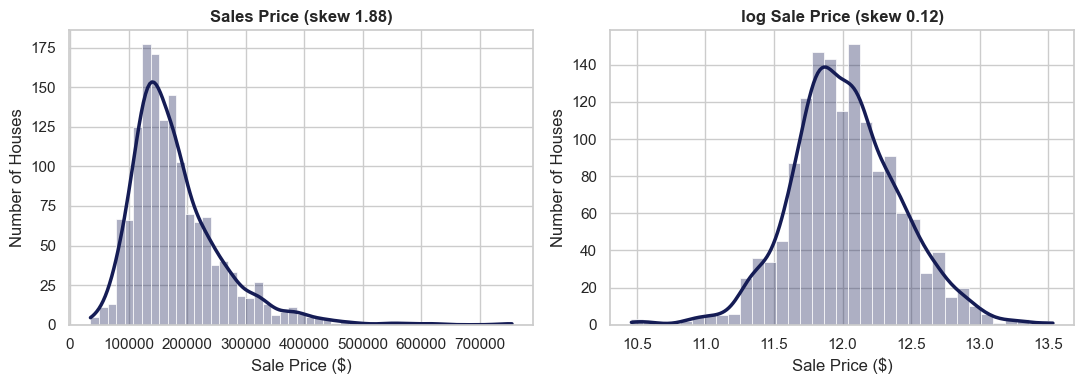

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(train["SalePrice"], kde=True, color = "#151C55", alpha=0.35,  edgecolor="white", linewidth=0.5, ax=ax[0],  line_kws={"color": "#C69200", "linewidth": 2.5})
ax[0].set_title(f'Sales Price (skew {train["SalePrice"].skew():.2f})', fontsize=12, fontweight="bold")
ax[0].set_xlabel("Sale Price ($)")
ax[0].set_ylabel("Number of Houses")

sns.histplot(np.log(train["SalePrice"]), color = "#151C55", alpha=0.35,edgecolor="white", linewidth=0.5,line_kws={"color": "#C69200", "linewidth": 2.5}, kde=True, ax=ax[1])
ax[1].set_title(f'log Sale Price (skew {np.log(train["SalePrice"]).skew():.2f})', fontsize=12,  fontweight="bold")
ax[1].set_xlabel("Sale Price ($)")
ax[1].set_ylabel("Number of Houses")
plt.tight_layout()

## 2.2 Missing values

*There are 34 columns with missing data. However, as shown in the figure below, the majority of these missing values represent the absence of a feature, such as a pool, garage, or fence, rather than a genuine data collection error. For example, a missing value in PoolQC simply indicates the property does not have a pool, and a missing value in GarageType indicates the property does not have a garage.*

*Given this, we treat most of these missing values as a meaningful category,  labeling them as "None" rather than imputing them statistically. Imputing these values would incorrectly suggest the feature exists but was unrecorded, when in fact the absence itself is informative and should be preserved as-is.*

count    34.000000
mean     15.826331
std      31.314324
min       0.034258
25%       0.034258
50%       1.747174
75%       5.447071
max      99.657417
dtype: float64

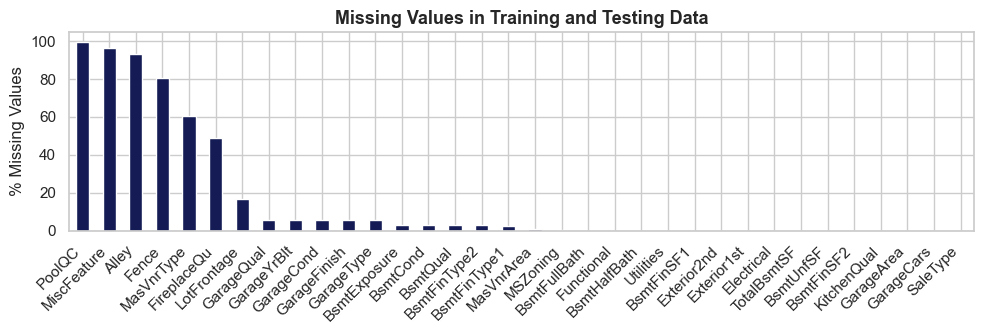

In [ ]:
# train and test together, since test has gaps train does not
all_raw = pd.concat([train.drop(columns=["SalePrice"]), test], ignore_index=True)

missing = all_raw.isnull().sum()
missing = (missing[missing > 0] / len(all_raw) * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 3.5))
missing.plot(kind="bar", color="#151C55")
plt.ylabel("% Missing Values")
plt.title("Missing Values in Training and Testing Data", fontsize=13, fontweight="bold")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
missing.describe()

To confirm that missing values represent genuine absence rather than data collection errors, we cross-referenced the categorical column against its corresponding size/quantity feature (e.g. PoolQC vs. PoolArea). In each case, the count of blank entries closely matched the count of properties with a size value of zero. With only a small number of mismatches. This confirms these are structurally missing rather than randomly missing data, which supports our decision to encode them as "None" rather than statistically impute them. Thus, we fill these with `"None"` and the matching area columns with `0`.

In [ ]:
# is a blank really "this house does not have one"? check against the matching size column
for cat, size in {"PoolQC": "PoolArea", "GarageType": "GarageArea", "BsmtQual": "TotalBsmtSF",
                  "FireplaceQu": "Fireplaces", "MasVnrType": "MasVnrArea"}.items():
    blank = all_raw[cat].isna()
    both = (blank & (all_raw[size].fillna(0) == 0)).sum()
    print(f"{cat:12s} blank: {blank.sum():5d}   of those with {size} = 0: {both:5d}")

PoolQC       blank:  2909   of those with PoolArea = 0:  2906
GarageType   blank:   157   of those with GarageArea = 0:   157
BsmtQual     blank:    81   of those with TotalBsmtSF = 0:    79
FireplaceQu  blank:  1420   of those with Fireplaces = 0:  1420
MasVnrType   blank:  1766   of those with MasVnrArea = 0:  1758


LotFrontage has missing values that need to be filled in. Before choosing how, we check whether frontage is consistent across the dataset or varies by neighbourhood.

overall median 68, neighbourhood medians 21 to 92


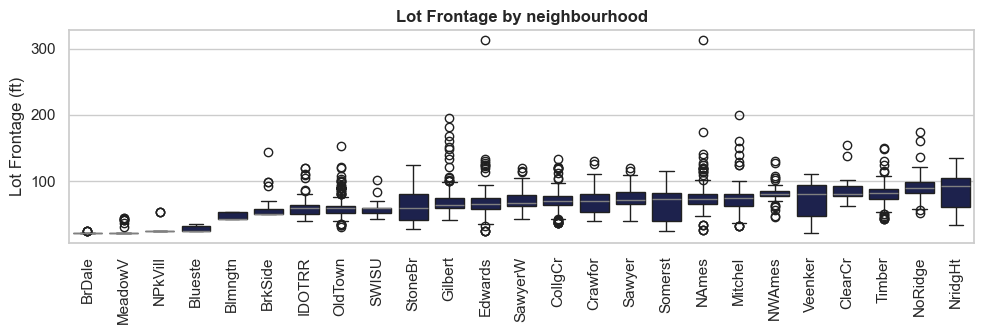

In [ ]:
# LotFrontage is the one column where we have to guess a number
plt.figure(figsize=(10, 3.5))
order = all_raw.groupby("Neighborhood")["LotFrontage"].median().sort_values().index
sns.boxplot(data=all_raw, x="Neighborhood", y="LotFrontage", order=order, color="#151C55",  medianprops={"color": "grey", "linewidth": 1} )
plt.xticks(rotation=90); plt.title("Lot Frontage by Neighbourhood", fontsize=12, fontweight="bold")
plt.xlabel("")
plt.ylabel("Lot Frontage (ft)")
plt.tight_layout()

nbhd = all_raw.groupby("Neighborhood")["LotFrontage"].median()
print(f"overall median {all_raw.LotFrontage.median():.0f}, neighbourhood medians {nbhd.min():.0f} to {nbhd.max():.0f}")

One overall median would be wrong by up to 35 feet depending on the neighbourhood, so we impute LotFrontage with the median of its own neighbourhood. Median rather than mean because lot sizes are right skewed.

## 2.3 Categorical variables

*Next, we explore the categorical columns in more detail. We start with how many there are, how many categories each one has, and a closer look at individual features like `Utilities`.*

In [ ]:
cats = all_raw.select_dtypes(include=[object])
print(f"{cats.shape[1]} categorical columns, at most {cats.nunique().max()} levels\n")
print(all_raw["Utilities"].value_counts(dropna=False))

43 categorical columns, at most 25 levels

Utilities
AllPub    2916
NaN          2
NoSeWa       1
Name: count, dtype: int64


`Utilities` has one non-`AllPub` house in the whole dataset, so it can only add noise. We drop it.

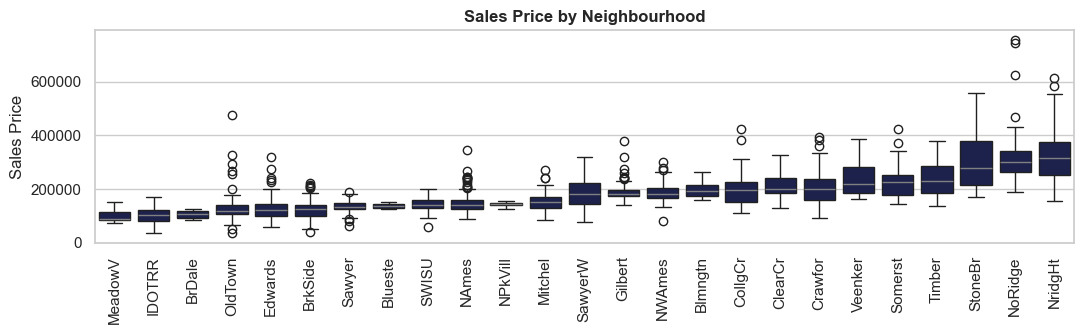

In [ ]:
plt.figure(figsize=(11, 3.5))
order = train.groupby("Neighborhood")["SalePrice"].median().sort_values().index
sns.boxplot(data=train, x="Neighborhood", y="SalePrice", order=order, color="#151C55",  medianprops={"color": "grey", "linewidth": 1})
plt.xticks(rotation=90); plt.title("Sales Price by Neighbourhood", fontsize=12, fontweight="bold")
plt.xlabel("")
plt.ylabel("Sales Price")
plt.tight_layout()

Median sale price varies more than three-fold across neighbourhoods, from around $100,000 in MeadowV to over $300,000 in NridgHt and StoneBr. `Neighborhood` therefore carries substantial price information on its own and is kept as a categorical predictor rather than collapsed into broader regions.

## 2.4 Correlations

*`OverallQual` (0.79) and `GrLivArea` (0.71) are by far the strongest predictors of `SalePrice`, confirming that quality rating and living area size are the two dominant drivers of price. Garage size (`GarageCars` 0.64, `GarageArea` 0.62), basement/first-floor size, and bathroom/room counts follow at a moderate strength (0.5–0.6).*

*The heatmap also reveals several predictor pairs that are highly correlated with *each other*, not just with price: `GarageCars` and `GarageArea` (0.88), `TotalBsmtSF` and `1stFlrSF` (0.82), `GrLivArea` and `TotRmsAbvGrd` (0.83), and `YearBuilt` and `GarageYrBlt` (0.83). This overlap means several features carry largely redundant information, a form of multicollinearity that can destabilize coefficient estimates in linear models such as OLS, motivating the use of regularized approaches (Ridge, Lasso) later in the modelling stage.*

SalePrice       1.000
OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507
GarageYrBlt     0.486


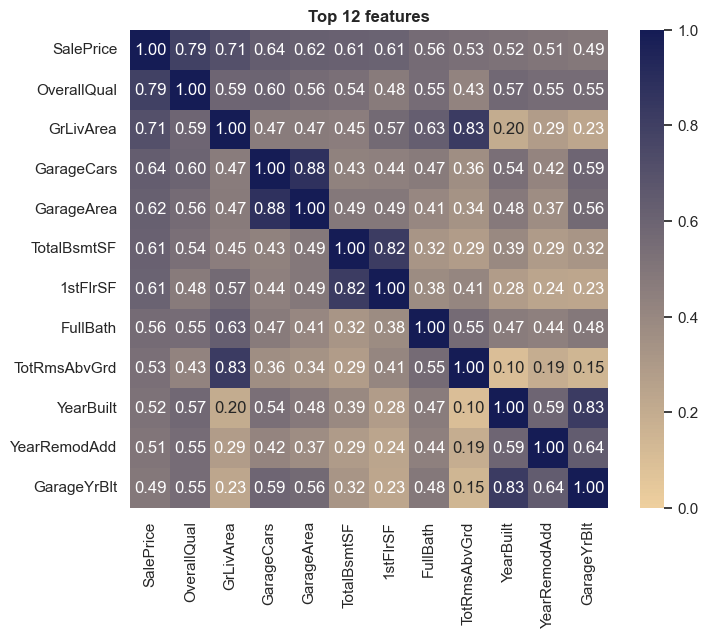

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

corr = train.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
print(corr.head(12).round(3).to_string())
top = corr.head(12).index

smu_branding = LinearSegmentedColormap.from_list(
    "brand_diverging",
    ["#C0392B", "#EFD09E", "#151C55"]  # red -> gold -> navy
)

plt.figure(figsize=(8, 6.5))
sns.heatmap(train[top].corr(), annot=True, fmt=".2f", cmap=smu_branding, center=0,vmin=0, square=True)
plt.title("Top 12 features",fontsize=12, fontweight="bold" ); plt.tight_layout()

In [ ]:
*We also check for pairs of predictors that are highly correlated with *each other*, not just with `SalePrice`, since these carry duplicate information.*

In [ ]:
# which predictors are near-duplicates of each other?
num = train.select_dtypes(include=[np.number]).drop(columns=["Id", "SalePrice"])
cm = num.corr().abs()
pairs = cm.where(np.triu(np.ones(cm.shape), k=1).astype(bool)).stack()
pairs[pairs > 0.8].sort_values(ascending=False).round(2)

GarageCars   GarageArea      0.88
YearBuilt    GarageYrBlt     0.83
GrLivArea    TotRmsAbvGrd    0.83
TotalBsmtSF  1stFlrSF        0.82
dtype: float64

Several predictors carry almost the same information. This is the reason plain OLS struggles later and the reason we reach for penalised regression: with near-duplicate columns the coefficients are barely identified, so they swing wildly between folds.

## 2.5 Outliers

,Id,GrLivArea,SalePrice,OverallQual,SaleCondition
523,524,4676,184750,10,Partial
691,692,4316,755000,10,Normal
1182,1183,4476,745000,10,Abnorml
1298,1299,5642,160000,10,Partial


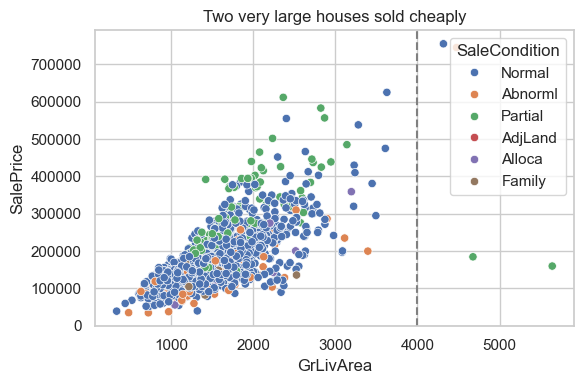

In [ ]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=train, x="GrLivArea", y="SalePrice", hue="SaleCondition")
plt.axvline(4000, ls="--", c="grey")
plt.title("Two very large houses sold cheaply"); plt.tight_layout()

train.loc[train.GrLivArea > 4000, ["Id", "GrLivArea", "SalePrice", "OverallQual", "SaleCondition"]]

Both cheap ones are `Partial` sales — sold before completion, so the recorded price is not a finished market price. They are the houses the dataset author warns about:

> "I would recommend removing any houses with more than 4000 square feet from the data set" — De Cock (2011)

We drop the two with `GrLivArea > 4000` **and** `SalePrice < 300000`. The other two are expensive as expected and stay.

# 3. Data cleaning

We clean train and test together so the same rules apply to both. The target is never involved, so no information about SalePrice leaks.

In [ ]:
outliers = train[(train.GrLivArea > 4000) & (train.SalePrice < 300000)].index
print(f"dropping Id {list(train.loc[outliers, 'Id'])}")

keep = ~train.index.isin(outliers)
y_all = np.log(train["SalePrice"])
ntrain = len(train)
all_data = pd.concat([train.drop(columns=["SalePrice"]), test], ignore_index=True)

dropping Id [524, 1299]


In [ ]:
# NA means the house does not have the feature
none_cols = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
             "GarageType", "GarageFinish", "GarageQual", "GarageCond",
             "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
             "MasVnrType"]
all_data[none_cols] = all_data[none_cols].fillna("None")

# same idea, but these are sizes and counts so the absence is 0
zero_cols = ["GarageYrBlt", "GarageArea", "GarageCars",
             "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
             "BsmtFullBath", "BsmtHalfBath", "MasVnrArea"]
all_data[zero_cols] = all_data[zero_cols].fillna(0)

all_data = all_data.drop(columns=["Utilities"])

# stored as numbers but they are labels
all_data["MSSubClass"] = all_data["MSSubClass"].astype(str)
all_data["MoSold"] = all_data["MoSold"].astype(str)

all_data["LotFrontage"] = all_data["LotFrontage"].fillna(
    all_data.groupby("Neighborhood")["LotFrontage"].transform("median")
)

In [ ]:
# whatever is left is a handful of cells with no better rule than "the usual value"
left = all_data.isnull().sum()
print(left[left > 0])

for c in left[left > 0].index:
    all_data[c] = all_data[c].fillna(all_data[c].mode()[0])
print("\nremaining missing:", all_data.isnull().sum().sum())

MSZoning       4
Exterior1st    1
Exterior2nd    1
Electrical     1
KitchenQual    1
Functional     2
SaleType       1
dtype: int64

remaining missing: 0


## 3.1 Ordinal encoding

Quality grades are ordered — `Ex` really is better than `Gd` — and one-hot encoding would throw that away. We map them to numbers, reserving 0 for "the house does not have this feature".

In [ ]:
ordinal_maps = {
    "ExterQual":    {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "ExterCond":    {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "BsmtQual":     {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "BsmtCond":     {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "BsmtExposure": {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},
    "BsmtFinType1": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "BsmtFinType2": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "HeatingQC":    {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "KitchenQual":  {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "FireplaceQu":  {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "GarageFinish": {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3},
    "GarageQual":   {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "GarageCond":   {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "PoolQC":       {"None": 0, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "Fence":        {"None": 0, "MnWw": 1, "GdWo": 2, "MnPrv": 3, "GdPrv": 4},
    "LandSlope":    {"Sev": 1, "Mod": 2, "Gtl": 3},
    "LotShape":     {"IR3": 1, "IR2": 2, "IR1": 3, "Reg": 4},
    "PavedDrive":   {"N": 1, "P": 2, "Y": 3},
    "Functional":   {"Sal": 1, "Sev": 2, "Maj2": 3, "Maj1": 4, "Mod": 5,
                     "Min2": 6, "Min1": 7, "Typ": 8},
    "Street":       {"Grvl": 0, "Pave": 1},
    "CentralAir":   {"N": 0, "Y": 1},
}
for col, mapping in ordinal_maps.items():
    all_data[col] = all_data[col].map(mapping).astype(int)

# sanity check: the grade should move with price
all_data.iloc[:ntrain].assign(SalePrice=np.exp(y_all)).groupby("KitchenQual")["SalePrice"].median().round(0)

KitchenQual
2    115000.0
3    137000.0
4    201400.0
5    316750.0
Name: SalePrice, dtype: float64

In [ ]:
# several predictors are as skewed as the target was, so log them too
numeric = all_data.select_dtypes(include=[np.number]).columns.drop("Id")

# decide which columns from the training rows we are keeping -- the two sales we are
# about to discard should not get a say in how the data is transformed
skewed = all_data.iloc[:ntrain][keep][numeric].skew()
skewed = skewed[skewed > 0.75].index

all_data[skewed] = np.log1p(all_data[skewed])
print(f"log1p applied to {len(skewed)} columns")

log1p applied to 25 columns


# 4. Preprocessing pipeline

Scaling matters for the penalised regressions and the SVR, which all compare coefficients or distances across columns; the tree models are indifferent to it. `handle_unknown="ignore"` means a category that only appears in test cannot break the model. Everything sits in a `Pipeline` so the scaler and encoder are fitted on training folds only.

In [ ]:
X_all = all_data.iloc[:ntrain].drop(columns=["Id"]).reset_index(drop=True)
X_test = all_data.iloc[ntrain:].drop(columns=["Id"]).reset_index(drop=True)
test_ids = test["Id"].values

# now drop the two flagged sales
X = X_all[keep].reset_index(drop=True)
y = y_all[keep].reset_index(drop=True)

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=[object]).columns.tolist()
print(f"{len(X)} rows, {len(numeric_features)} numeric and {len(categorical_features)} categorical columns")

1458 rows, 55 numeric and 23 categorical columns


In [ ]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

# a Pipeline fits its steps in place, so every model gets its own copy
def make_pipe(model):
    return Pipeline([("pre", clone(preprocessor)), ("model", model)])

print("design matrix:", preprocessor.fit_transform(X).shape)

design matrix: (1458, 246)


# 5. Models

The Kaggle test set has no labels, so every decision comes from the 1,458 training rows. We use **5-fold cross-validation on all of them**, with the same folds for every model and every hyperparameter choice, scoring RMSE on `log(SalePrice)`.

We tune on cross-validation rather than a single held-out split. An earlier version of this notebook used one 20% split, and the model it chose scored *worse* on the leaderboard despite scoring better in our own validation — see the submission log in section 7.1.

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_rmse(model, X, y):
    oof = cross_val_predict(make_pipe(model), X, y, cv=kf)
    return np.sqrt(mean_squared_error(y, oof)), oof

## 5.1 Baseline: ordinary least squares

In [ ]:
ols_rmse, ols_oof = cv_rmse(LinearRegression(), X, y)
print(f"OLS  CV RMSE = {ols_rmse:.4f}")
print(f"{preprocessor.fit_transform(X).shape[1]} columns fitted on {int(len(X) * 0.8)} rows per fold")

OLS  CV RMSE = 0.1317
246 columns fitted on 1166 rows per fold


OLS is the obvious starting point and the worst model we fit. Section 2.4 showed several predictors are near-duplicates, and after encoding we estimate 250-odd coefficients from about 1,170 rows per fold. The fit is close to singular, so coefficients are unstable and predictions swing on unseen folds. Regularisation is the fix.

## 5.2 Ridge and Lasso

Both shrink coefficients; the penalty strength `alpha` is chosen by internal cross-validation rather than by hand. Ridge keeps every column and pulls correlated ones together, Lasso sets weak coefficients to exactly zero and so doubles as feature selection.

In [ ]:
ridge = RidgeCV(alphas=np.logspace(-2, 3, 50))
ridge_rmse, ridge_oof = cv_rmse(ridge, X, y)
print(f"Ridge  CV RMSE = {ridge_rmse:.4f}")

lasso = LassoCV(alphas=np.logspace(-4, -2.5, 6), max_iter=2000, random_state=RANDOM_STATE)
lasso_rmse, lasso_oof = cv_rmse(lasso, X, y)
print(f"Lasso  CV RMSE = {lasso_rmse:.4f}")

Ridge  CV RMSE = 0.1138
Lasso  CV RMSE = 0.1124


In [ ]:
lasso_fit = make_pipe(lasso).fit(X, y)
lasso_coefs = lasso_fit.named_steps["model"].coef_
best_alpha = lasso_fit.named_steps["model"].alpha_

print(f"lasso alpha = {best_alpha:.5f}  ->  kept {(lasso_coefs != 0).sum()} of {len(lasso_coefs)} columns")

lasso alpha = 0.00040  ->  kept 113 of 246 columns


Lasso switches off more than half the encoded columns on its own. That is our answer to whether the feature set is too wide: the penalty is already doing the selection, and it re-decides inside every fold, where dropping columns by hand would mean committing once and hoping.

## 5.3 Support vector regression

A different idea: instead of minimising squared error over every house, an SVR ignores any house it already prices within a tolerance `epsilon` and fits only to the ones outside it, using an RBF kernel to allow curvature. `C` controls how hard it pushes on those, `gamma` how local the kernel is. We grid-search both on the same folds as everything else.

`epsilon` is fixed at 0.01: on the log scale that is a tolerance band of about 1% in price, which is finer than we could hope to predict anyway.

In [ ]:
svr_rows, svr_oofs = [], {}
for C in [10, 30, 100]:
    for gamma in [0.0001, 0.0003, 0.001]:
        score, oof = cv_rmse(SVR(C=C, gamma=gamma, epsilon=0.01), X, y)
        svr_rows.append({"C": C, "gamma": gamma, "cv_rmse": score})
        svr_oofs[(C, gamma)] = oof

svr_grid = pd.DataFrame(svr_rows).sort_values("cv_rmse").reset_index(drop=True)
svr_grid.round(4)

,C,gamma,cv_rmse
0,30,0.0003,0.1112
1,100,0.0001,0.1119
2,10,0.0003,0.1125
3,100,0.0003,0.1127
4,10,0.0010,0.1128
5,30,0.0001,0.1133
6,10,0.0001,0.1149
7,30,0.0010,0.1171
8,100,0.0010,0.1270


In [ ]:
best = svr_grid.iloc[0]
svr = SVR(C=int(best.C), gamma=best.gamma, epsilon=0.01)
svr_oof = svr_oofs[(int(best.C), best.gamma)]
svr_rmse = best.cv_rmse
print(f"chosen: C={int(best.C)}, gamma={best.gamma}  ->  CV RMSE = {svr_rmse:.4f}")

chosen: C=30, gamma=0.0003  ->  CV RMSE = 0.1112


## 5.4 XGBoost

Boosted trees, so no linearity assumption and interactions come for free. Depth is the setting that matters at this sample size — deeper trees memorise — so that is what we search. `subsample` and `colsample_bytree` are left at the usual values, which decorrelate the trees.

In [ ]:
xgb_rows, xgb_oofs = [], {}
for depth in [2, 3, 4]:
    model = XGBRegressor(max_depth=depth, n_estimators=600, learning_rate=0.06,
                         min_child_weight=2, subsample=0.8, colsample_bytree=0.5,
                         random_state=RANDOM_STATE, n_jobs=4)
    score, oof = cv_rmse(model, X, y)
    xgb_rows.append({"max_depth": depth, "cv_rmse": score})
    xgb_oofs[depth] = (model, oof)

xgb_grid = pd.DataFrame(xgb_rows).sort_values("cv_rmse").reset_index(drop=True)
xgb_grid.round(4)

,max_depth,cv_rmse
0,3,0.1151
1,4,0.1151
2,2,0.1151


In [ ]:
best_depth = int(xgb_grid.iloc[0].max_depth)
xgb, xgb_oof = xgb_oofs[best_depth]
xgb_rmse = xgb_grid.iloc[0].cv_rmse
print(f"chosen: depth {best_depth}  ->  CV RMSE = {xgb_rmse:.4f}")

chosen: depth 3  ->  CV RMSE = 0.1151


## 5.5 Gradient boosting with a Huber loss

A second tree model, chosen because the Huber loss fits the middle of the distribution and refuses to chase the far tail — the natural counterweight to the odd sales we deliberately kept in section 2.5.

In [ ]:
gbr = GradientBoostingRegressor(
    n_estimators=400, learning_rate=0.07, max_depth=3,
    max_features="sqrt", min_samples_leaf=5,
    loss="huber", random_state=RANDOM_STATE,
)
gbr_rmse, gbr_oof = cv_rmse(gbr, X, y)
print(f"GradientBoosting  CV RMSE = {gbr_rmse:.4f}")

GradientBoosting  CV RMSE = 0.1159


# 6. Evaluation

In [ ]:
models = {"OLS": ols_oof, "Ridge": ridge_oof, "Lasso": lasso_oof,
          "SVR": svr_oof, "XGBoost": xgb_oof, "GradientBoosting": gbr_oof}

results = pd.DataFrame({"model": list(models),
                        "cv_rmse": [np.sqrt(mean_squared_error(y, p)) for p in models.values()]})
results.sort_values("cv_rmse").round(4).reset_index(drop=True)

,model,cv_rmse
0,SVR,0.1112
1,Lasso,0.1124
2,Ridge,0.1138
3,XGBoost,0.1151
4,GradientBoosting,0.1159
5,OLS,0.1317


*To write: four models land within about 0.003 of each other by completely different routes — a penalised regression, a kernel method and two tree ensembles. That agreement suggests we are near the ceiling of what these 79 features can say about price.*

## 6.1 Averaging the models

The good models are wrong in different places, so averaging cancels part of the error. We use a **plain average** rather than fitted weights — we tested optimal weights and they gained 0.0002 in-sample and *lost* when fitted honestly on held-out folds, so equal weights are both simpler and better.

In [ ]:
picks = ["Lasso", "SVR", "XGBoost", "GradientBoosting"]

print("correlation between the models' errors:")
print(pd.DataFrame({m: y - models[m] for m in picks}).corr().round(2))

blend_oof = np.mean([models[m] for m in picks], axis=0)
blend_rmse = np.sqrt(mean_squared_error(y, blend_oof))
print(f"\nbest single model : {results.cv_rmse.min():.4f}")
print(f"average of four   : {blend_rmse:.4f}")

correlation between the models' errors:
                  Lasso   SVR  XGBoost  GradientBoosting
Lasso              1.00  0.94     0.84              0.83
SVR                0.94  1.00     0.84              0.85
XGBoost            0.84  0.84     1.00              0.90
GradientBoosting   0.83  0.85     0.90              1.00

best single model : 0.1112
average of four   : 0.1077


## 6.2 Where the accuracy came from

*To write: two bad rows out of 1,460 cost about as much as leaving the model untuned, and finding them took one scatter plot. Note the asymmetry in effort.*

In [ ]:
fixed = Lasso(alpha=best_alpha, max_iter=2000)
kept_rmse, _ = cv_rmse(fixed, X_all, y_all)
default_rmse, _ = cv_rmse(XGBRegressor(random_state=RANDOM_STATE, n_jobs=4), X, y)

pd.DataFrame({
    "decision": ["remove the 2 partial sales", "tune XGBoost rather than use defaults",
                 "average 4 models instead of 1"],
    "before": [kept_rmse, default_rmse, results.cv_rmse.min()],
    "after":  [lasso_rmse, xgb_rmse, blend_rmse],
}).assign(gain=lambda d: (d.before - d.after).round(4)).round(4)

,decision,before,after,gain
0,remove the 2 partial sales,0.1315,0.1124,0.0192
1,tune XGBoost rather than use defaults,0.1364,0.1151,0.0213
2,average 4 models instead of 1,0.1112,0.1077,0.0035


## 6.3 Residuals

*To write: are the residuals unbiased across the price range, and what do the worst misses have in common?*

R2 on the log scale     : 0.927
median error in dollars : 8,679


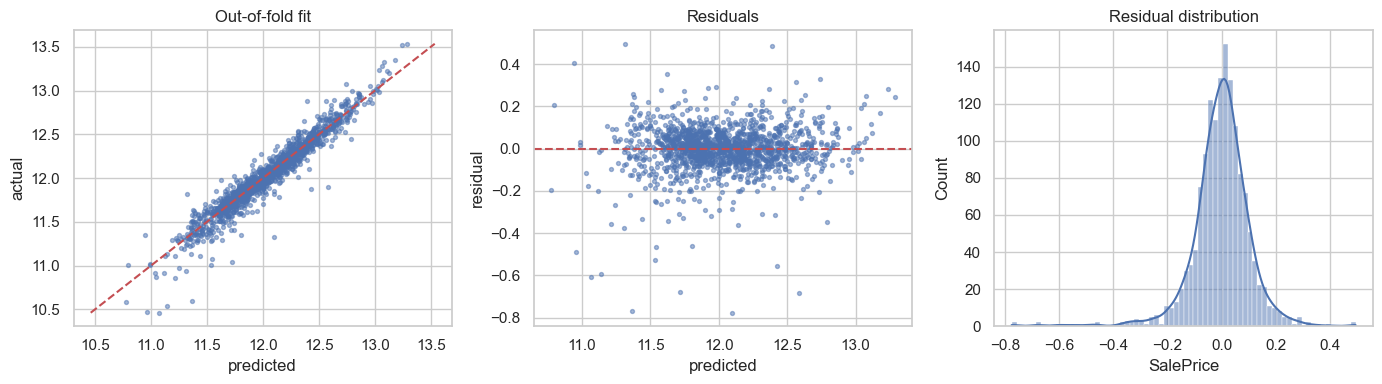

In [ ]:
resid = y - blend_oof

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].scatter(blend_oof, y, s=8, alpha=0.5)
ax[0].plot([y.min(), y.max()], [y.min(), y.max()], "r--")
ax[0].set_xlabel("predicted"); ax[0].set_ylabel("actual"); ax[0].set_title("Out-of-fold fit")

ax[1].scatter(blend_oof, resid, s=8, alpha=0.5); ax[1].axhline(0, c="r", ls="--")
ax[1].set_xlabel("predicted"); ax[1].set_ylabel("residual"); ax[1].set_title("Residuals")

sns.histplot(resid, kde=True, ax=ax[2]); ax[2].set_title("Residual distribution")
plt.tight_layout()

print(f"R2 on the log scale     : {r2_score(y, blend_oof):.3f}")
print(f"median error in dollars : {np.median(np.abs(np.exp(y) - np.exp(blend_oof))):,.0f}")

In [ ]:
worst = resid.abs().sort_values(ascending=False).head(8).index
train.loc[worst, ["Id", "GrLivArea", "OverallQual", "SaleCondition", "SalePrice"]].assign(
    predicted=np.exp(blend_oof[worst]).round(0)
)

,Id,GrLivArea,OverallQual,SaleCondition,SalePrice,predicted
631,632,1554,8,Normal,209500,179445.0
30,31,1317,4,Normal,40000,86349.0
1322,1323,1923,7,Normal,190000,291722.0
462,463,864,5,Normal,62383,122861.0
495,496,720,4,Abnorml,34900,64111.0
967,968,1098,5,Normal,135000,68723.0
587,588,860,5,Normal,137000,249481.0
410,411,1276,5,Abnorml,60000,101901.0


## 6.4 What the models use

*To write: the linear model and the tree model agree on the top handful, which suggests the signal is real rather than an artefact of one algorithm. Do not read individual coefficients too closely — section 2.4 showed the columns are collinear, so credit for an effect can move between them.*

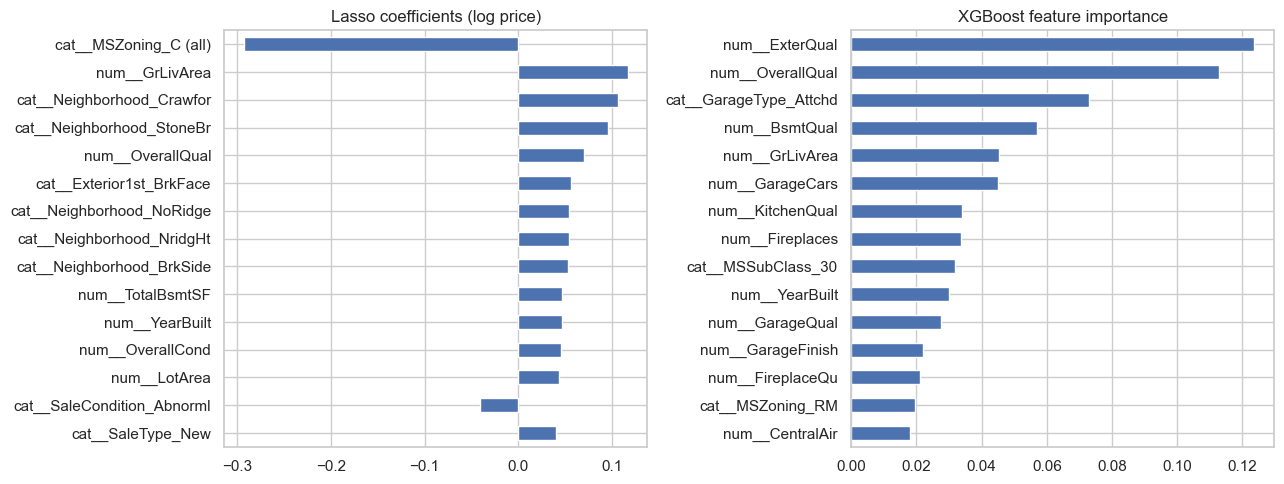

In [ ]:
xgb_fit = make_pipe(xgb).fit(X, y)
names = lasso_fit.named_steps["pre"].get_feature_names_out()

lasso_top = pd.Series(lasso_coefs, index=names)
lasso_top = lasso_top[lasso_top != 0].sort_values(key=abs, ascending=False).head(15)
xgb_top = pd.Series(xgb_fit.named_steps["model"].feature_importances_, index=names).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
lasso_top.iloc[::-1].plot(kind="barh", ax=ax[0], title="Lasso coefficients (log price)")
xgb_top.iloc[::-1].plot(kind="barh", ax=ax[1], title="XGBoost feature importance")
plt.tight_layout()

# 7. Kaggle submission

## 7.1 Submission log

Kaggle allows ten submissions a day, so each one has to earn its slot.

| # | Models | What changed | CV RMSE | Public LB |
| --- | --- | --- | --- | --- |
| 1 | Lasso + XGBoost | first working blend, XGBoost set by hand | 0.1086 | 0.12447 |
| 2 | Lasso + XGBoost | tuned XGBoost against a single 20% split | 0.1080 | 0.12540 |
| 3 | Lasso + XGBoost + GBR | tuning moved to 5-fold CV, added Huber boosting | 0.1078 | 0.12417 |
| 4 | Lasso + SVR + XGBoost + GBR | added SVR | 0.1068 | **0.12315** |

**Submission 2 is the one worth presenting.** It has a better cross-validated score than submission 1 and a worse leaderboard score. That is single-split tuning fitting the noise in 292 particular rows: our validation number improved because we had picked settings that suited those rows, not because the model got better. Everything since has been tuned on 5-fold CV, and the two scores have moved together.

*To write: this table is the refinement narrative the report asks for. Four submissions, one of which went backwards, and we can say exactly why.*

## 7.2 Building the files

The models are refitted on all 1,458 rows. We write two files — the four-model average and the best single model — because CV and the leaderboard are scored on different houses and it is worth seeing whether they agree.

In [ ]:
svr_fit = make_pipe(svr).fit(X, y)
gbr_fit = make_pipe(gbr).fit(X, y)

test_preds = {"Lasso": lasso_fit.predict(X_test), "SVR": svr_fit.predict(X_test),
              "XGBoost": xgb_fit.predict(X_test), "GradientBoosting": gbr_fit.predict(X_test)}

blend = np.mean([test_preds[m] for m in picks], axis=0)
pd.DataFrame({"Id": test_ids, "SalePrice": np.exp(blend)}).to_csv("submission_blend.csv", index=False)

best_single = results.sort_values("cv_rmse").iloc[0].model
pd.DataFrame({"Id": test_ids, "SalePrice": np.exp(test_preds[best_single])}).to_csv("submission_single.csv", index=False)

print(f"submission_blend.csv   average of {len(picks)} models, CV {blend_rmse:.4f}")
print(f"submission_single.csv  {best_single} alone, CV {results.cv_rmse.min():.4f}")

submission_blend.csv   average of 4 models, CV 0.1077
submission_single.csv  SVR alone, CV 0.1112


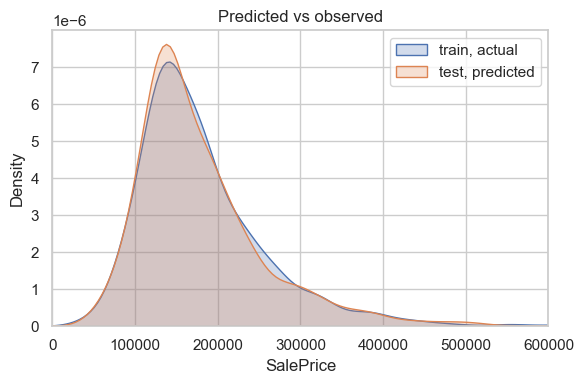

In [ ]:
# sanity check: predicted prices should look like the prices we trained on
plt.figure(figsize=(6, 4))
sns.kdeplot(np.exp(y), label="train, actual", fill=True)
sns.kdeplot(np.exp(blend), label="test, predicted", fill=True)
plt.xlim(0, 600000); plt.xlabel("SalePrice"); plt.legend()
plt.title("Predicted vs observed"); plt.tight_layout()

# 8. Conclusion

*To write:*
- *how well the model did: CV RMSE, leaderboard score, typical error in dollars*
- *the biggest lesson: two bad rows out of 1,460 cost about as much accuracy as leaving the model untuned, and finding them took one scatter plot rather than any modelling*
- *the second: submission 2 improved our own validation score and got worse on the leaderboard. How you validate is a modelling decision like any other.*
- *the third: the data dictionary told us NA meant "no basement", not "unknown" — a domain fact no algorithm could recover on its own*
- *the fourth: our first working model scored 0.12447 and our last scored 0.12315. Most of the accuracy was in understanding the data, not in the models.*
- *what we would do next: neighbourhood-level external data, target encoding, a stacked meta-learner*
- *a closing sentence that ties it together*

**References**

- De Cock, D. (2011). Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester Regression Project. *Journal of Statistics Education*, 19(3).
- Kaggle, *House Prices - Advanced Regression Techniques*.